# $\mathcal{N}^{10} + \mathcal{N}^{25} + \mathcal{N}^{50} \in \mathbb{R}^{100} $

### Setup environment

In [80]:
import sys, os, importlib
print(sys.path)

PATH_ROOT  = "/root/workspace/Python/flipd/"
PATH_MODEL = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


### Load data

### Train VP SDE

In [7]:
from models.training import LightweightTrainer
from models.diffusions.training import LightningDiffusion
from functools import partial
import torch.optim as optim
import torch
import numpy as np
from tqdm import tqdm

from models.diffusions.sdes import VpSde, VeSde
from models.diffusions.networks import MLPUnet

device = torch.device('cuda:1')

import matplotlib.pyplot as plt
import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
from visualization.pretty import ColorTheme

from data.distributions import AffineManifoldMixture
from data.datasets.generated import LIDSyntheticDataset

ambient_dim = 100

distribution = AffineManifoldMixture(
    manifold_dims=[10, 25, 50],
    ambient_dim=ambient_dim,
    sample_distr="normal",
    affine_projection_type="random-rotation",
    #mixture_probs=[0.5, 0.25, 0.25], 
    seed=111,
    distance_between_modes=10,
)

dset = LIDSyntheticDataset(size=500_000, distribution=distribution, standardize=True, seed=42)

In [4]:
score_net = MLPUnet(ambient_dim, hidden_sizes=(1024, 1024, 512, 512, 256, 128), time_embedding_dim=128).to(device)
vp_sde = VpSde(score_net=score_net).to(device)
training_module = LightningDiffusion(sde=vp_sde,optim_partial=partial(optim.Adam, lr=1e-4),)
trainer = LightweightTrainer(max_epochs=251,device=device,)
trainer.fit(
    model=training_module,
    train_dataloader=torch.utils.data.DataLoader(dset.x.to(device), batch_size=2000),
    ckpt_path= os.path.join(PATH_MODEL, "100D_10d_25d_50d_gaussian_vp"),
)

Training epochs [Batch 250/250]: 100%|██████████| 251/251 [09:21<00:00,  3.72s/it, loss=11]  


In [86]:
IS_CONV2D = True

if IS_CONV2D:
    from models.diffusions.networks import UNet2D
    ambient_dim_img = (1, 10, 10)
    if True:
        score_net = UNet2D(
            sample_size=10, in_channels=1,out_channels=1, layers_per_block=2,
            # 3 down blocks results in 10 → 5 → 2.5 → 1.25
            # block_out_channels=(64, 128, 128),
            # down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
            # up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
            block_out_channels=(128, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D",),
            t_factor=1000,   # matches your adapter’s timestep scaling
        ).to(device)
        ckpt_path= os.path.join(PATH_MODEL, "100D_10d_25d_50d_gaussian_unet2d_vp")
    else:
        score_net = UNet2D(
            sample_size=10, in_channels=1,out_channels=1, layers_per_block=2,
            block_out_channels=(128, 256, 256),
            down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
            t_factor=1000,
        ).to(device)
        ckpt_path= os.path.join(PATH_MODEL, "100D_10d_25d_50d_gaussian_idr_unet2d_rich_vp")

    class UNet2DFlatAdapter(torch.nn.Module):
        """
        Wrap a trained UNet2D that expects (B,1,28,28) so it can be used
        with flat inputs (B,784) and returns flat outputs (B,784).
        """
        def __init__(self, unet2d: torch.nn.Module, H: int = 28, W: int = 28, C: int = 1):
            super().__init__()
            self.unet2d = unet2d   # your trained UNet2D (diffusers adapter)
            self.H, self.W, self.C = H, W, C
            self.D = C * H * W

        def forward(self, x, t):
            # x can be (B,D) or already (B,C,H,W)
            if x.ndim == 2:
                B = x.shape[0]
                x = x.view(B, self.C, self.H, self.W)
            elif x.ndim == 4:
                B = x.shape[0]
            else:
                raise ValueError(f"Expected x.ndim in {{2,4}}, got {x.ndim}")
            out = self.unet2d(x, t)          # (B,1,28,28)
            return out.view(B, self.D)       # flatten back to (B,D)

    adapter = UNet2DFlatAdapter(score_net, H=10, W=10, C=1).to(device)
    vp_sde = VpSde(score_net=adapter).to(device)
else:
    score_net = MLPUnet(ambient_dim, hidden_sizes=(1024, 1024, 512, 512, 256, 128), time_embedding_dim=128).to(device)
    ckpt_path= os.path.join(PATH_MODEL, "100D_10d_25d_50d_gaussian_vp")
    vp_sde = VpSde(score_net=score_net).to(device)

print(ckpt_path)

trainer = LightweightTrainer(max_epochs=299, device=device,)
trainer.fit(
    model=LightningDiffusion(sde=vp_sde, optim_partial=partial(optim.Adam, lr=1e-4)),
    train_dataloader=torch.utils.data.DataLoader(dset.x.to(device), batch_size=2000, shuffle=True),
    ckpt_path=ckpt_path,
)

/root/workspace/Python/flipd/notebooks/outputs/notebooks/100D_10d_25d_50d_gaussian_unet2d_vp


Training: 100%|██████████| 299/299 [00:00<?, ?it/s]


### VE SDE

In [ ]:
if True:
    ve_sde = VeSde(score_net=score_net).to(device)
    training_module = LightningDiffusion(sde=ve_sde,optim_partial=partial(optim.Adam, lr=1e-4),)
    trainer = LightweightTrainer(max_epochs=301,device=device,)
    trainer.fit(
        model=training_module,
        train_dataloader=torch.utils.data.DataLoader(dset.x.to(device), batch_size=2000),
        ckpt_path= os.path.join(PATH_MODEL, "100D_10d_25d_50d_gaussian_ve"),
    )

### Generate and visualize samples to check the model trained properly

Iterating the solver: 100%|██████████| 1000/1000 [00:15<00:00, 64.02it/s]


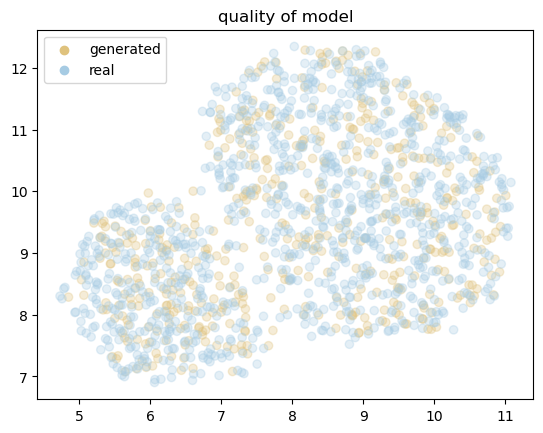

In [8]:
from visualization import visualize_3d_clusters
from visualization import visualize_umap_clusters
from visualization.pretty import ColorTheme

n_samples = 500

noise = torch.randn(n_samples, ambient_dim).to(device)
vp_sde: VpSde
gen_samples = vp_sde.solve_reverse_sde(noise, steps=1000)

# visualize_3d_clusters(
#     data  = [dset.x[:n_samples].cpu().numpy()],
#     gt_lid = [dset.lid[:n_samples].cpu().numpy()],
#     labels=["real"],
#     title="Ground truth",
#     alpha=0.7,
#     return_img=False,
# )

visualize_umap_clusters(
    data = [gen_samples.cpu().detach().numpy(), dset.x[:1000].cpu().numpy()],
    labels=["generated", "real"],
    title="quality of model",
    alpha=0.3,
    colors=[ColorTheme.GOLD.value, ColorTheme.BLUE_SECOND.value],
    return_img=False,
)

## LID Estimation

In [112]:
# reload for debug 
import importlib, sys
importlib.invalidate_caches()

import lid.base as lid_base
importlib.reload(lid_base)

from lid.diffusions import local_hessian_spectrum as lhs
importlib.reload(lhs)

import lid.diffusions as lid_diffusions
importlib.reload(lid_diffusions)

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)

batch_size = 10000
lid_estimator_soft_dof = LocalHessianSpectralEstimator(vp_sde, VPSchedule(beta_min=0.1, beta_max=20.0), method="Soft_DoF", 
                                                       soft_c=0.5, soft_p=12,
                                                       ambient_dim=ambient_dim, device=device, batch_size=batch_size)
lid_estimator_logistic_dof = LocalHessianSpectralEstimator(vp_sde, VPSchedule(beta_min=0.1, beta_max=20.0), method="Logistic_DoF",
                                                        log_c=0.7, log_wscale=0.1,
                                                        ambient_dim=ambient_dim, device=device, batch_size=batch_size)

from lid.evaluation.lid_evaluation import mae
#dgrid = np.linspace(0.001, 0.1, 16)

n_samples = 500
data = dset.x[:n_samples].to(device)
gt_lid = dset.lid[:n_samples].to(device).cpu().numpy()


# delta = 0.05 # 1.7952053720474244
deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid_soft_dof = lid_estimator_soft_dof.estimate_lid(data, delta=delta).cpu().numpy()
    print('SoftDoF:', delta, mae(lid_soft_dof, gt_lid))

lid_logistic_dof = lid_estimator_logistic_dof.estimate_lid(data, delta=delta).cpu().numpy()
print('LogisticDoF:', mae(lid_logistic_dof, gt_lid))


SoftDoF: 0.001 45.66410265731812
SoftDoF: 0.029428571428571432 1.9262760372161865
SoftDoF: 0.057857142857142864 1.9326196146011352
SoftDoF: 0.0862857142857143 1.8187467079162598
SoftDoF: 0.11471428571428573 1.7508803224563598
SoftDoF: 0.14314285714285716 1.7485715885162354
SoftDoF: 0.1715714285714286 1.747032829284668
SoftDoF: 0.2 1.781267846107483
LogisticDoF: 2.158209734916687


In [95]:
n_samples = 500

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [100]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=ambient_dim, device=device,)

deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid_nb = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
    print('NB:', delta, mae(lid_nb, gt_lid))

NB: 0.001 73.09
NB: 0.029428571428571432 30.366
NB: 0.057857142857142864 2.14
NB: 0.0862857142857143 1.158
NB: 0.11471428571428573 2.056
NB: 0.14314285714285716 6.472
NB: 0.2 23.396


In [113]:
delta = 0.171571428571428
lid_nb = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
print('NB:', delta, mae(lid_nb, gt_lid))

NB: 0.171571428571428 16.204


## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid_lidl = lid_estimator_lidl.estimate_lid(data, delta=1e-3).detach().cpu().numpy()
print('LIDL:', mae(lid_lidl, gt_lid))

LIDL: 76.07911806259155


## Competitor - FLIPD

In [102]:
from lid.diffusions.fokker_planck import FlipdEstimator
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)

deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid_flipd = lid_estimator_flipd.estimate_lid(data, t=delta).detach().cpu().numpy()
    print('FLIPD:', delta, mae(lid_flipd, gt_lid))

FLIPD: 0.001 57.3397569732666
FLIPD: 0.029428571428571432 3.8011677951812746
FLIPD: 0.057857142857142864 2.3953933544158934
FLIPD: 0.0862857142857143 2.2638673458099365
FLIPD: 0.11471428571428573 2.0286008949279783
FLIPD: 0.14314285714285716 1.587649347305298
FLIPD: 0.1715714285714286 1.3422988109588623
FLIPD: 0.2 1.3137302322387696


... saved /root/workspace/Python/flipd/notebooks/figs/100D_10d_25d_50d_gaussian.png


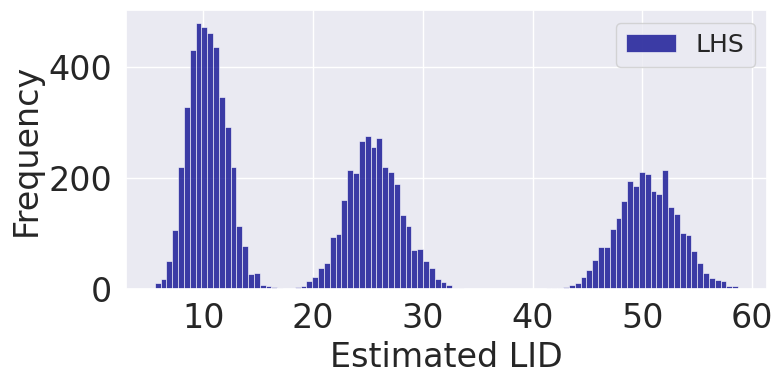

In [78]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

filename = os.path.join(PATH_FIG, "100D_10d_25d_50d_gaussian")
plot_histograms([lid_soft_dof], labels=['LHS'], filename=filename)

## Competitor - ESS

In [15]:
!pip install scikit-dimension

In [16]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="ESS")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS:', mae(lid, gt_lid))

ESS: 15.161296311497269


## Competitor - LPCA

In [17]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="lPCA")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA:', mae(lid, gt_lid))

LPCA: 18.638
